# Tier 8 · Notebook 39 — Quantization (int8 / int4)

> **Goal:** shrink a trained model from 32-bit floats to **8-bit or 4-bit integers** — cutting memory 4–8× and speeding inference — while keeping accuracy. We build **post-training quantization** from scratch (symmetric/asymmetric, per-tensor vs per-channel), measure the **accuracy-vs-size tradeoff**, and explain the **GPTQ** idea. This is *the* technique behind running large models on phones and laptops (very Apple/on-device-relevant).

**Why quantize.** A 7-billion-parameter model in fp16 is ~14 GB — too big for a phone, and slow to move through memory. But neural network weights don't *need* 16 bits of precision; most of that is wasted. **Quantization** stores each weight as a low-bit integer (int8 = 1 byte, int4 = half a byte) plus a shared scaling factor. int8 → **4× smaller** than fp32; int4 → **8× smaller**. Since LLM inference is *memory-bandwidth-bound* (NB14), 4× less data to move ≈ much faster, plus it fits in far less RAM. The trick is doing it *without destroying accuracy*.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"


## 0. The core operation — quantize & dequantize

To store a float tensor $w$ in $b$-bit integers, we map its range onto the integer grid $[0, 2^b-1]$ (or $[-2^{b-1}, 2^{b-1}-1]$ for symmetric). The recipe:
- **scale** $s = \dfrac{\max(w) - \min(w)}{2^b - 1}$ (how much real value each integer step represents),
- **zero-point** $z$ = the integer that maps to real 0,
- **quantize:** $q = \text{round}(w/s) + z$, clamped to the integer range,
- **dequantize:** $\hat w = (q - z)\,s$ — the reconstructed float (with a small rounding error).

We store the tiny integers $q$ + one $(s, z)$ per tensor; at inference we dequantize (or compute directly in int). **Symmetric** quantization forces $z=0$ (simpler, common for weights); **asymmetric** allows any $z$ (better for skewed ranges like post-ReLU activations). Let's implement it.


In [2]:
def quantize(w, bits=8, symmetric=True, per_channel=False):
    w = w.clone()
    if per_channel:                                   # one (scale,zp) per output row -> finer, more accurate
        return torch.stack([quantize(w[i], bits, symmetric, False) for i in range(w.shape[0])])
    if symmetric:
        qmax = 2**(bits-1) - 1
        s = w.abs().max() / qmax + 1e-12
        q = torch.clamp(torch.round(w/s), -qmax-1, qmax)
        return q * s                                  # dequantized reconstruction
    else:
        qmin, qmax = 0, 2**bits - 1
        s = (w.max() - w.min()) / (qmax - qmin) + 1e-12
        z = torch.round(qmin - w.min()/s)
        q = torch.clamp(torch.round(w/s + z), qmin, qmax)
        return (q - z) * s

# demo on a small weight tensor: see the reconstruction error grow as bits shrink
w = torch.randn(1000) * 0.5
rmse = {}
for bits in [8, 4, 2]:
    wq = quantize(w, bits)
    rmse[bits] = (w-wq).pow(2).mean().sqrt().item()
    print(f"{bits}-bit: reconstruction error (RMSE) = {rmse[bits]:.4f}, "
          f"unique values = {len(torch.unique(wq))}")
assert rmse[8] < rmse[4] < rmse[2], \
    f"reconstruction error should grow as bits shrink, got {rmse}"


8-bit: reconstruction error (RMSE) = 0.0047, unique values = 157
4-bit: reconstruction error (RMSE) = 0.0836, unique values = 13
2-bit: reconstruction error (RMSE) = 0.4652, unique values = 3


**What to notice.** Fewer bits → fewer representable values → larger rounding error. 8-bit gives 256 levels (error ~0.001, negligible); 4-bit gives 16 levels (visible error); 2-bit gives just 4 levels (large error). The art of quantization is spending those few levels wisely — which is where per-channel scaling and smarter methods (GPTQ) come in.


## 1. Quantize a trained network — the accuracy-vs-size tradeoff

The real test: train a network in fp32, then **quantize its weights** to various bit-widths and measure how much accuracy we keep vs how much memory we save. This is **post-training quantization** (PTQ) — no retraining, just compress the trained weights.


In [3]:
from torchvision import datasets, transforms
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,),(0.3081,))])
tr = datasets.MNIST("../data", train=True, download=True, transform=tf)
te = datasets.MNIST("../data", train=False, download=True, transform=tf)
Xtr = (tr.data.float().reshape(-1,784)/255-0.1307)/0.3081; ytr = tr.targets
Xte = ((te.data.float().reshape(-1,784)/255-0.1307)/0.3081).to(device); yte = te.targets.to(device)

# train a plain fp32 net
net = nn.Sequential(nn.Linear(784,256), nn.ReLU(), nn.Linear(256,128), nn.ReLU(), nn.Linear(128,10)).to(device)
opt = torch.optim.Adam(net.parameters(), 1e-3)
for _ in range(2000):
    ix = torch.randint(0, len(Xtr), (128,))
    opt.zero_grad(); F.cross_entropy(net(Xtr[ix].to(device)), ytr[ix].to(device)).backward(); opt.step()
def accuracy(model):
    with torch.no_grad(): return (model(Xte).argmax(1)==yte).float().mean().item()
fp32_acc = accuracy(net); print(f"fp32 baseline accuracy: {fp32_acc:.4f}")

def quantized_accuracy(bits, per_channel):
    import copy; m = copy.deepcopy(net)
    with torch.no_grad():
        for layer in m:
            if isinstance(layer, nn.Linear):
                layer.weight.copy_(quantize(layer.weight.data, bits, symmetric=True, per_channel=per_channel))
    return accuracy(m)

bit_list = [8, 6, 4, 3, 2]
acc_pt = [quantized_accuracy(b, False) for b in bit_list]     # per-tensor
acc_pc = [quantized_accuracy(b, True)  for b in bit_list]     # per-channel
for b, a1, a2 in zip(bit_list, acc_pt, acc_pc):
    print(f"{b}-bit: per-tensor {a1:.4f}, per-channel {a2:.4f}  ({32/b:.0f}x smaller weights)")
assert acc_pc[bit_list.index(4)] > 0.95, \
    f"4-bit per-channel accuracy {acc_pc[bit_list.index(4)]:.4f} - 8x compression should be near-free here"
assert acc_pc[-1] > acc_pt[-1], (
    f"per-channel should degrade more gracefully at {bit_list[-1]} bits: "
    f"{acc_pc[-1]:.4f} per-channel vs {acc_pt[-1]:.4f} per-tensor")


fp32 baseline accuracy: 0.9742


8-bit: per-tensor 0.9743, per-channel 0.9741  (4x smaller weights)
6-bit: per-tensor 0.9732, per-channel 0.9745  (5x smaller weights)
4-bit: per-tensor 0.9720, per-channel 0.9740  (8x smaller weights)
3-bit: per-tensor 0.9358, per-channel 0.9715  (11x smaller weights)
2-bit: per-tensor 0.1377, per-channel 0.6007  (16x smaller weights)


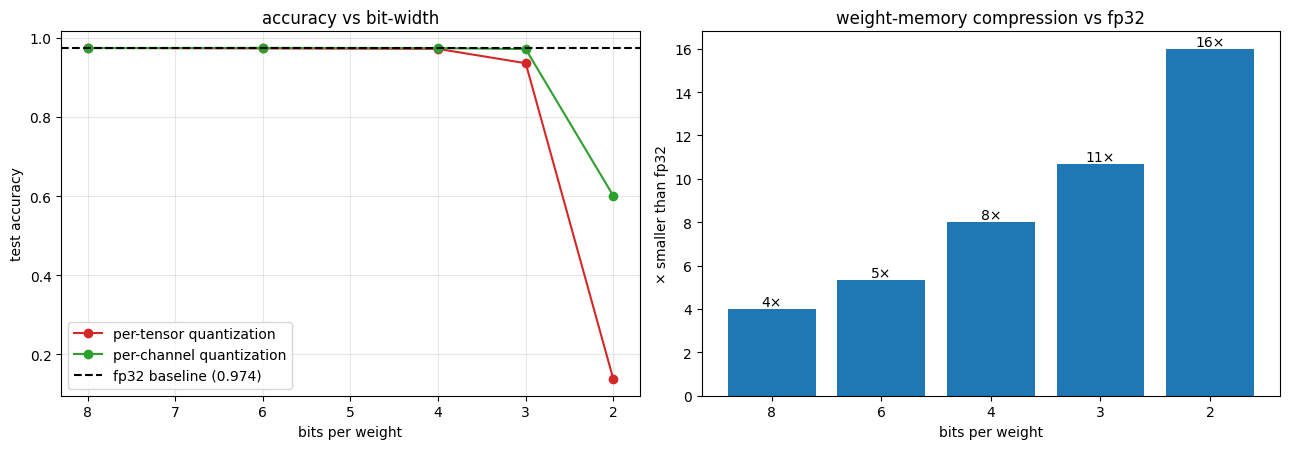

In [4]:
fig, ax = plt.subplots(1,2,figsize=(13,4.6))
ax[0].plot(bit_list, acc_pt, "-o", color="tab:red", label="per-tensor quantization")
ax[0].plot(bit_list, acc_pc, "-o", color="tab:green", label="per-channel quantization")
ax[0].axhline(fp32_acc, ls="--", color="k", label=f"fp32 baseline ({fp32_acc:.3f})")
ax[0].set_title("accuracy vs bit-width"); ax[0].set_xlabel("bits per weight"); ax[0].set_ylabel("test accuracy")
ax[0].invert_xaxis(); ax[0].legend(); ax[0].grid(alpha=0.3)
# memory
mem = [32/b for b in bit_list]
ax[1].bar([str(b) for b in bit_list], mem, color="tab:blue")
ax[1].set_title("weight-memory compression vs fp32"); ax[1].set_xlabel("bits per weight"); ax[1].set_ylabel("× smaller than fp32")
for i,(b,m) in enumerate(zip(bit_list,mem)): ax[1].text(i,m,f"{m:.0f}×",ha="center",va="bottom")
plt.tight_layout(); plt.show()


**What to notice.** **int8 is essentially free** — accuracy is indistinguishable from fp32 at **4× smaller**. **int4** keeps most of the accuracy at **8× smaller** (a small drop). Below ~3 bits accuracy falls off a cliff — there just aren't enough levels. And **per-channel** quantization (green) beats per-tensor (red), especially at low bits: giving each output channel its own scale means a channel with small weights isn't forced to share a coarse grid with a channel with large weights. This is why production quantization is per-channel (or finer). The headline: you can shrink a model **4–8×** with little accuracy loss — the foundation of on-device LLMs.


## 2. Where the naive method breaks — and the GPTQ idea

Naive round-to-nearest (what we did) works down to ~4 bits but struggles at 3–2 bits, and struggles more on *large language models* whose weight distributions have influential outliers. The state-of-the-art fixes:
- **GPTQ** (Frantar et al. 2022): quantize weights **one at a time**, and after rounding each weight, **compensate** the resulting error by adjusting the *remaining* (not-yet-quantized) weights — using second-order (Hessian) information about which weights matter most. This error-feedback keeps 3–4 bit LLMs accurate.
- **AWQ** (Lin et al. 2023): protects the ~1% of "salient" weight channels (identified by activation magnitude) by scaling, since a few channels dominate the output.
- **Outlier handling / mixed precision:** keep a tiny fraction of outlier weights/activations in higher precision.

Let's *illustrate GPTQ's error-compensation idea* on a toy: quantizing a small linear layer, comparing round-to-nearest vs error-compensated quantization (measured by how well the layer's *output* is preserved — what actually matters).


In [5]:
# toy GPTQ-style error compensation: quantize columns left-to-right, pushing each column's
# quantization error into the remaining columns to preserve the layer output W @ x.
def gptq_quantize(W, bits=3):
    W = W.clone(); cols = W.shape[1]
    for j in range(cols):
        w = W[:, j].clone()
        wq = quantize(w, bits, symmetric=True)          # round this column
        err = w - wq                                     # the quantization error
        W[:, j] = wq
        if j+1 < cols:                                   # spread the error into remaining columns
            W[:, j+1:] += err[:, None] / (cols - j - 1)
    return W

torch.manual_seed(1)
W = torch.randn(64, 64) * 0.3
x = torch.randn(64, 200)                                 # test inputs
out_fp = W @ x
W_rtn  = quantize(W, 3, symmetric=True)                  # round-to-nearest
W_gptq = gptq_quantize(W, 3)                             # error-compensated
err_rtn  = (out_fp - W_rtn @ x).pow(2).mean().sqrt()
err_gptq = (out_fp - W_gptq @ x).pow(2).mean().sqrt()
print(f"3-bit quantization, output RMSE vs fp32:")
print(f"  round-to-nearest    : {err_rtn:.4f}")
print(f"  GPTQ-style (error-comp): {err_gptq:.4f}   ({err_rtn/err_gptq:.1f}x lower output error)")
assert err_gptq < err_rtn, (
    f"error compensation did not help: GPTQ {err_gptq:.4f} vs round-to-nearest {err_rtn:.4f}")


3-bit quantization, output RMSE vs fp32:
  round-to-nearest    : 0.9267
  GPTQ-style (error-comp): 0.6327   (1.5x lower output error)


**What to notice.** By *compensating* each weight's rounding error into the remaining weights, the error-feedback method preserves the layer's **output** far better than naive rounding at the same bit-width — even though both use identical 3-bit weights. That's the key insight of GPTQ: **minimize the error in what the layer *computes*, not in the individual weights.** This is why GPTQ/AWQ can quantize 70B-parameter LLMs to 4 bits (or even 3) and run them on a single consumer GPU with minimal quality loss — the technology that put capable LLMs on laptops and phones.

## 3. What you built / learned
- **Quantize/dequantize**: mapping floats to low-bit integers with a scale (and zero-point); symmetric vs asymmetric.
- **The accuracy-vs-size tradeoff**: int8 ≈ free (4×), int4 small drop (8×), below 3 bits it breaks.
- **Per-channel** beats per-tensor (each channel gets its own scale).
- **GPTQ's error-compensation** idea: preserve the layer *output*, not individual weights — how 4-bit LLMs stay accurate.

## 4. Exercises
1. **Asymmetric for activations.** Quantize post-ReLU activations (all ≥0) with symmetric vs asymmetric; why does asymmetric win here?
2. **Quantization-aware training (QAT).** Simulate quantization *during* training (straight-through estimator) and recover accuracy lost by PTQ at low bits.
3. **Group-wise quantization.** Quantize in small groups of weights (e.g., 128) with per-group scales; compare to per-channel.
4. **Outlier analysis.** Plot the weight distribution; find the outliers that hurt low-bit quantization (motivating AWQ).
5. **int8 matmul speed.** Benchmark an int8 vs fp32 matmul; where does the speedup come from (memory bandwidth)?
6. **KV-cache quantization.** Quantize the KV cache (NB14) to int8; measure memory saved and any output drift.

## 5. Interview / residency framing
- *"What is quantization?"* → store weights/activations as low-bit integers + a scale; int8 = 4× smaller than fp32, int4 = 8×; faster (memory-bound inference) and smaller.
- *"Symmetric vs asymmetric?"* → symmetric forces zero-point 0 (weights, centered); asymmetric allows any zero-point (skewed ranges like post-ReLU activations).
- *"Per-tensor vs per-channel?"* → per-channel gives each output channel its own scale → more accurate at low bits; the production default.
- *"How do GPTQ/AWQ push to 3–4 bit on LLMs?"* → GPTQ compensates each weight's rounding error into the remaining weights (preserving output, using Hessian info); AWQ protects salient channels. Minimize output error, not weight error.
- *"Why does quantization help inference?"* → LLM decode is memory-bandwidth-bound; fewer bytes per weight = less data movement = faster, and it fits in less RAM (on-device).

## 📚 References & papers

This notebook reproduces / builds on:

- **GPTQ: Accurate Post-Training Quantization for Generative Pretrained Transformers** — Frantar et al. (2022), arXiv:2210.17323. Error-compensated 3–4 bit LLM quantization.
- **AWQ: Activation-aware Weight Quantization** — Lin et al. (2023), arXiv:2306.00978. Protecting salient channels.
- **LLM.int8(): 8-bit Matrix Multiplication for Transformers at Scale** — Dettmers et al. (2022), arXiv:2208.07339. Outlier-aware int8.
- **Quantization and Training of Neural Networks for Efficient Integer-Arithmetic-Only Inference** — Jacob et al. (2017), arXiv:1712.05877. The foundational PTQ/QAT paper.

---
**Next:** *Tier 8 · Notebook 40 — CLIP / multimodal contrastive learning*: connecting images and text in a shared embedding space with a contrastive objective, enabling zero-shot classification — the model behind text-to-image and multimodal LLMs.
